In [ ]:
!pip install --upgrade neuralforecast


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.0 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour i

In [ ]:
import pandas as pd

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, mape, bias

In [ ]:
df = pd.read_parquet('/content/sample_hotels-1.parquet')
df['ds'] = pd.to_datetime(df['ds'])
df = df.query("unique_id not in ['hotel_77', 'hotel_28']")

In [ ]:
test_df = df.groupby('unique_id').tail(28).reset_index(drop=True)
train_df = df.groupby('unique_id').apply(lambda x: x.iloc[:-28]).reset_index(drop=True)


/tmp/ipykernel_1690/3000690409.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = df.groupby('unique_id').apply(lambda x: x.iloc[:-28]).reset_index(drop=True)


In [ ]:
train_df['y'] = train_df['y'].astype('float32')


In [ ]:
models = [
    NBEATS(
        h=28,
        input_size=56,
    ),
    NHITS(
        h=28,
        input_size=56,
    )
]

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
nf = NeuralForecast(
    models=models,
    freq='D'
)

In [ ]:
nf.fit(train_df[['unique_id', 'ds', 'y']])

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [ ]:
cv_nf = nf.cross_validation(
    df=train_df[['unique_id', 'ds', 'y']],
    h=28,
    step_size=28,
    n_windows=5
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
eval_nf = evaluate(
    df = cv_nf,
    metrics=[mae, rmse, mape, bias],
    models=['NBEATS', 'NHITS']
)

display(eval_nf)

,unique_id,cutoff,metric,NBEATS,NHITS
0,hotel_0,2023-01-13,mae,0.105882,0.142846
1,hotel_105,2023-01-13,mae,0.101696,0.101172
2,hotel_112,2023-01-13,mae,0.096346,0.164633
3,hotel_126,2023-01-13,mae,0.127319,0.156887
4,hotel_133,2023-01-13,mae,0.086564,0.112286
...,...,...,...,...,...
335,hotel_7,2023-05-05,bias,0.013076,-0.018444
336,hotel_70,2023-05-05,bias,-0.014313,0.035030
337,hotel_84,2023-05-05,bias,0.017648,-0.003690
338,hotel_91,2023-05-05,bias,0.002705,-0.077739


In [ ]:
eval_nf_avg = (
    eval_nf
    .drop(columns=['cutoff'], errors='ignore')
    .groupby(['unique_id', 'metric'], as_index=False)
    .mean(numeric_only=True)
)

In [ ]:
display(eval_nf_avg)

,unique_id,metric,NBEATS,NHITS
0,hotel_0,bias,0.022452,-0.005604
1,hotel_0,mae,0.104392,0.129100
2,hotel_0,mape,0.169601,0.204313
3,hotel_0,rmse,0.134653,0.168009
4,hotel_105,bias,-0.026728,-0.006865
...,...,...,...,...
63,hotel_91,rmse,0.123843,0.155881
64,hotel_98,bias,0.014562,-0.002087
65,hotel_98,mae,0.094237,0.074134
66,hotel_98,mape,0.486168,0.373705


In [ ]:
models = ['NBEATS', 'NHITS']

eval_nf_avg[models] = eval_nf_avg[models].apply(pd.to_numeric, errors='coerce')

eval_nf_avg['winner'] = eval_nf_avg[models].idxmin(axis=1)

In [ ]:
nf_win_counts = (
    eval_nf_avg
    .groupby(['metric', 'winner'])
    .size()
    .reset_index(name='wins')
)

display(nf_win_counts)

,metric,winner,wins
0,bias,NBEATS,6
1,bias,NHITS,11
2,mae,NBEATS,10
3,mae,NHITS,7
4,mape,NBEATS,9
5,mape,NHITS,8
6,rmse,NBEATS,10
7,rmse,NHITS,7


In [ ]:
nf.fit(train_df[['unique_id', 'ds', 'y']])
forecast_nf = nf.predict()

results_test_nf = forecast_nf.merge(test_df, on=['unique_id', 'ds'])

eval_test_nf = evaluate(
    df=results_test_nf,
    metrics=[bias, mae, rmse, mape],
    models=['NBEATS', 'NHITS']
)
display(eval_test_nf)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,metric,NBEATS,NHITS
0,hotel_0,bias,0.013522,0.056690
1,hotel_105,bias,-0.110993,-0.043997
2,hotel_112,bias,-0.005813,0.022028
3,hotel_126,bias,-0.040919,-0.027682
4,hotel_133,bias,0.003864,0.005780
...,...,...,...,...
63,hotel_7,mape,0.370484,0.391211
64,hotel_70,mape,0.271283,0.273291
65,hotel_84,mape,0.109608,0.143374
66,hotel_91,mape,0.073273,0.083726


In [ ]:
eval_test_nf.to_csv('neural_test_eval.csv', index=False)
results_test_nf.to_csv('neural_test_forecasts.csv', index=False)

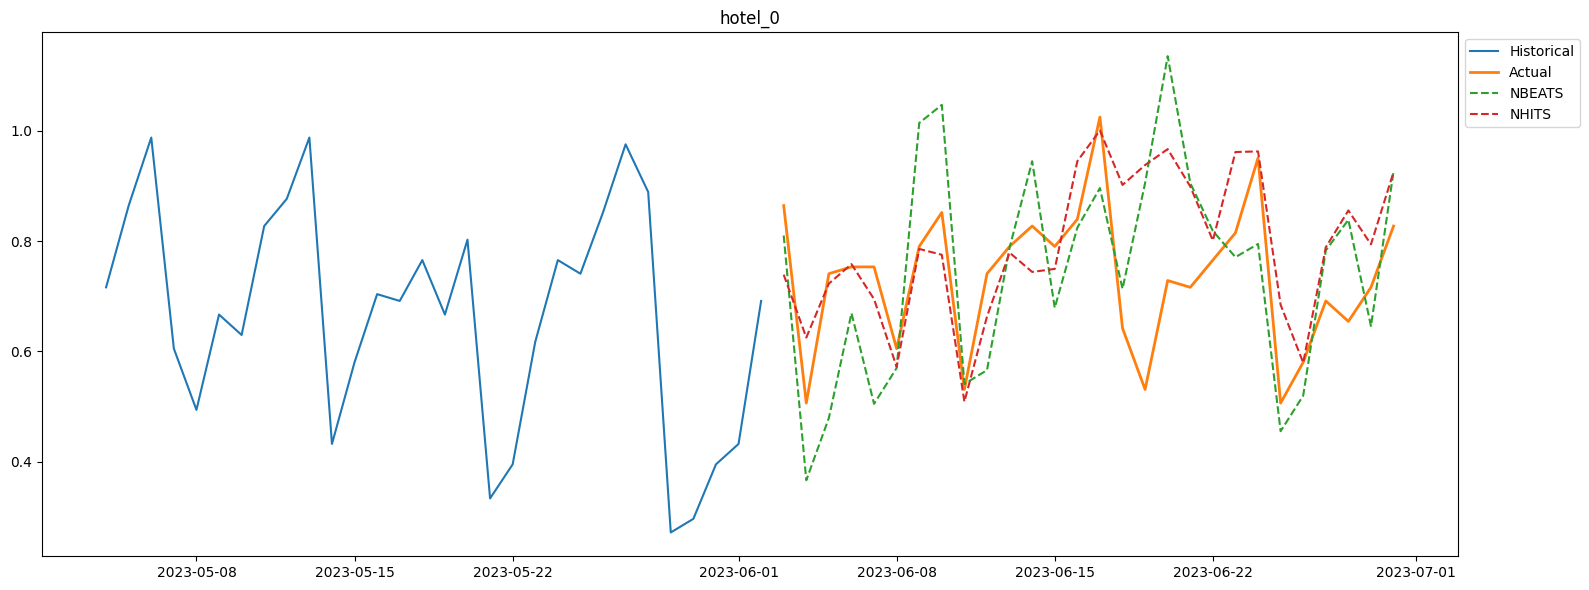

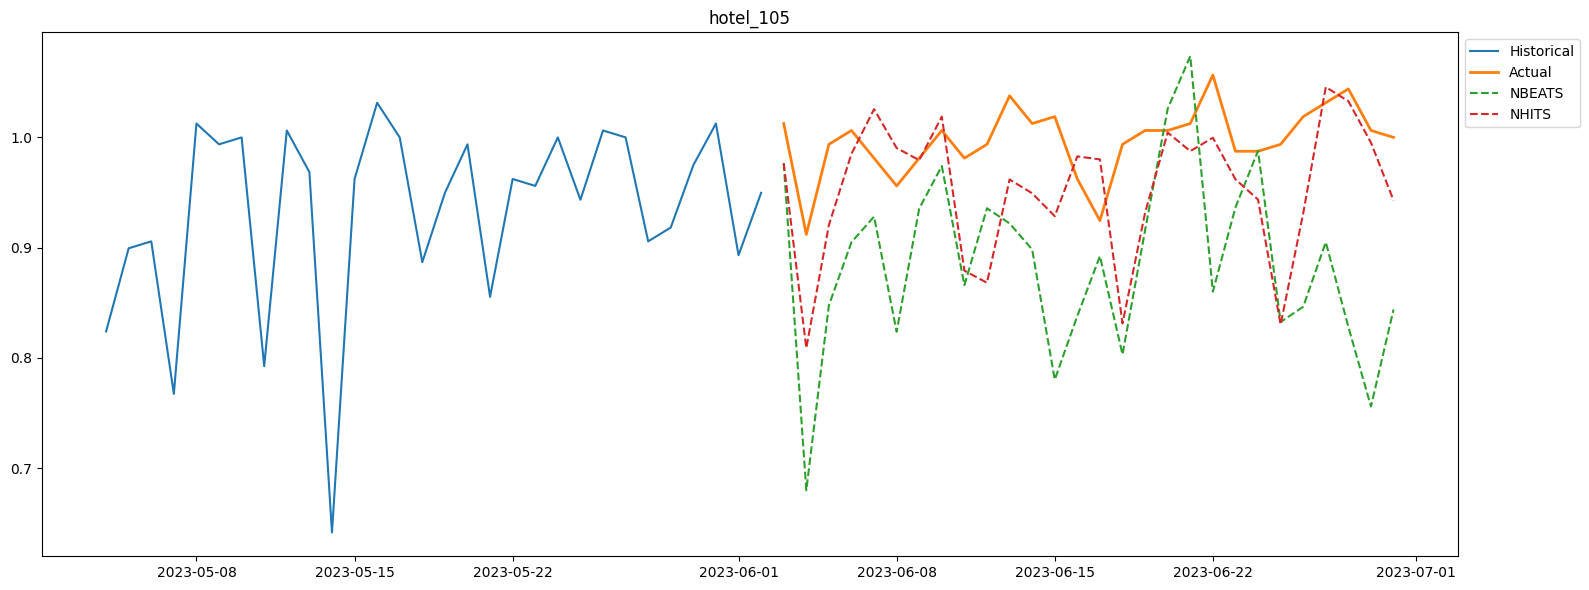

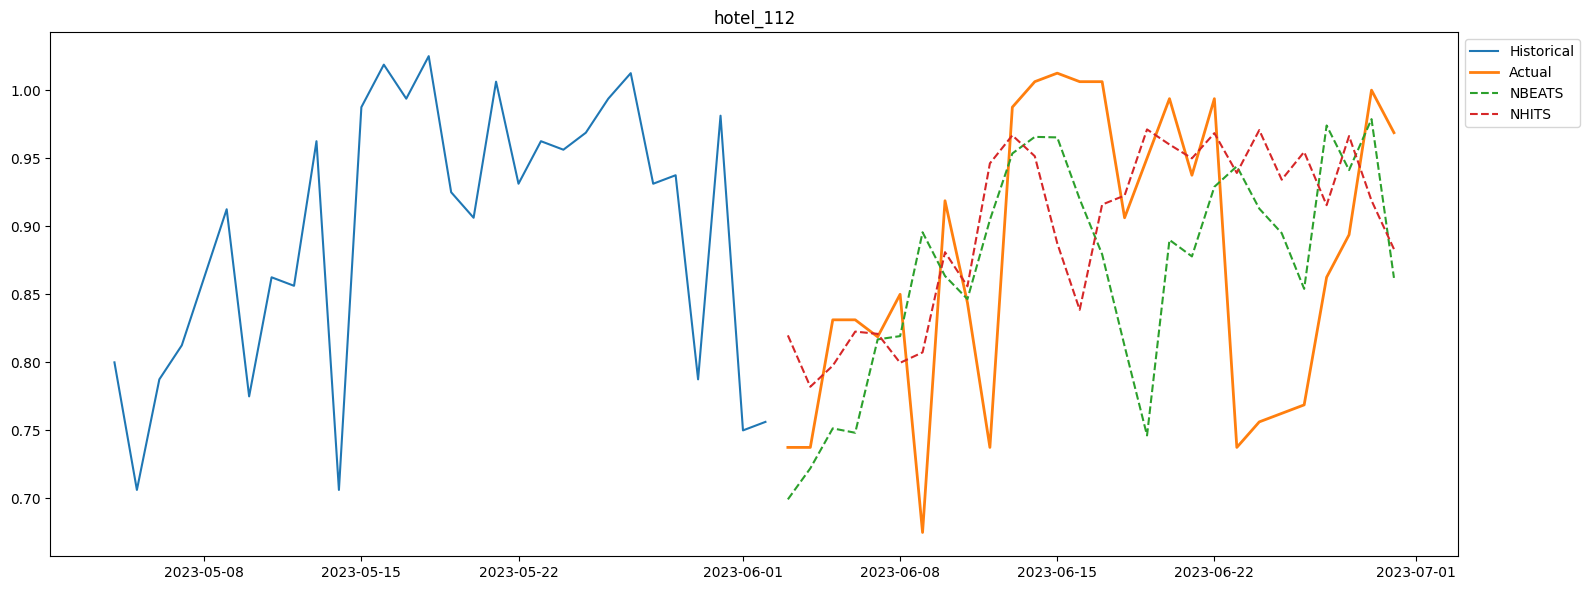

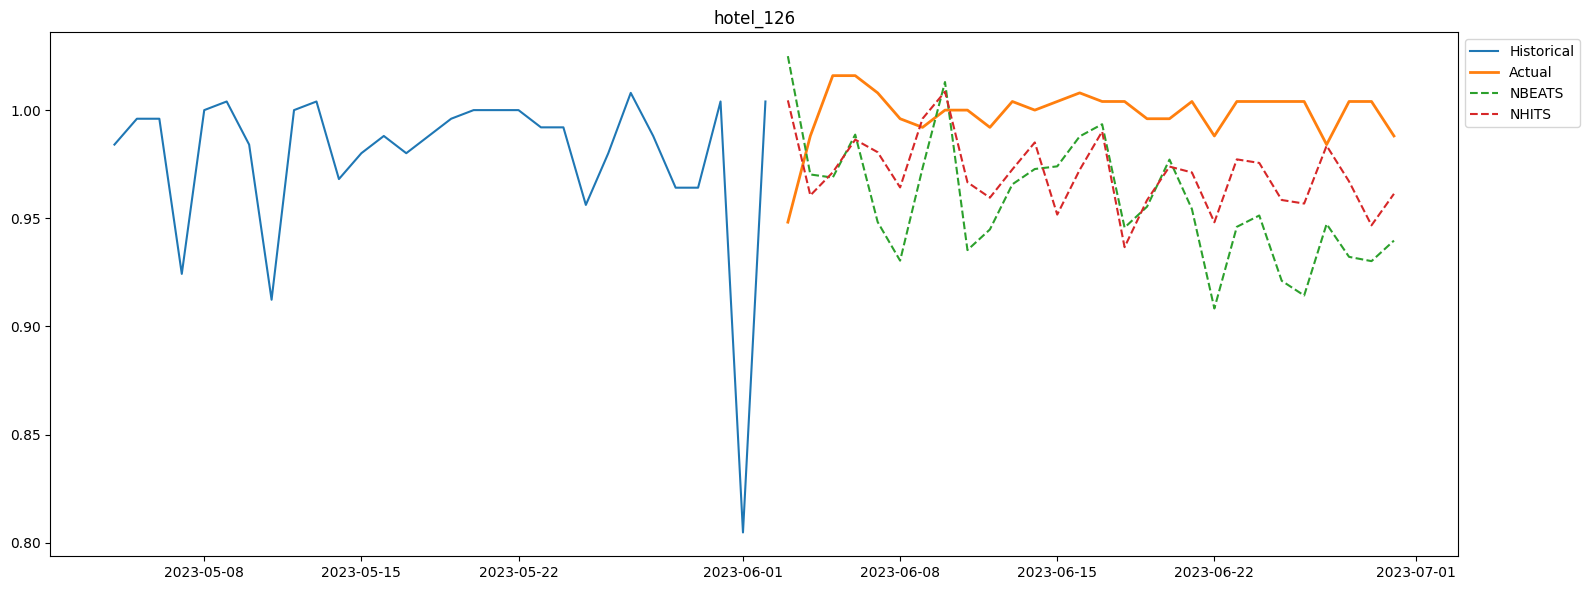

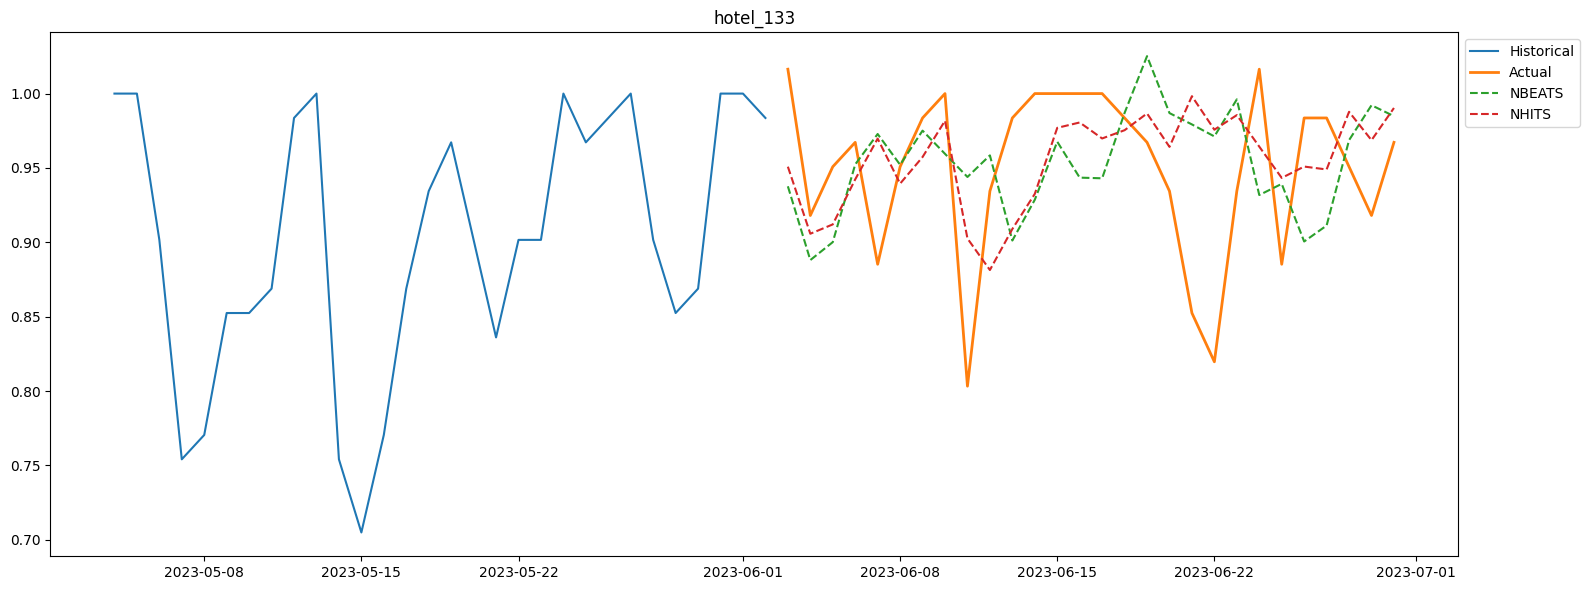

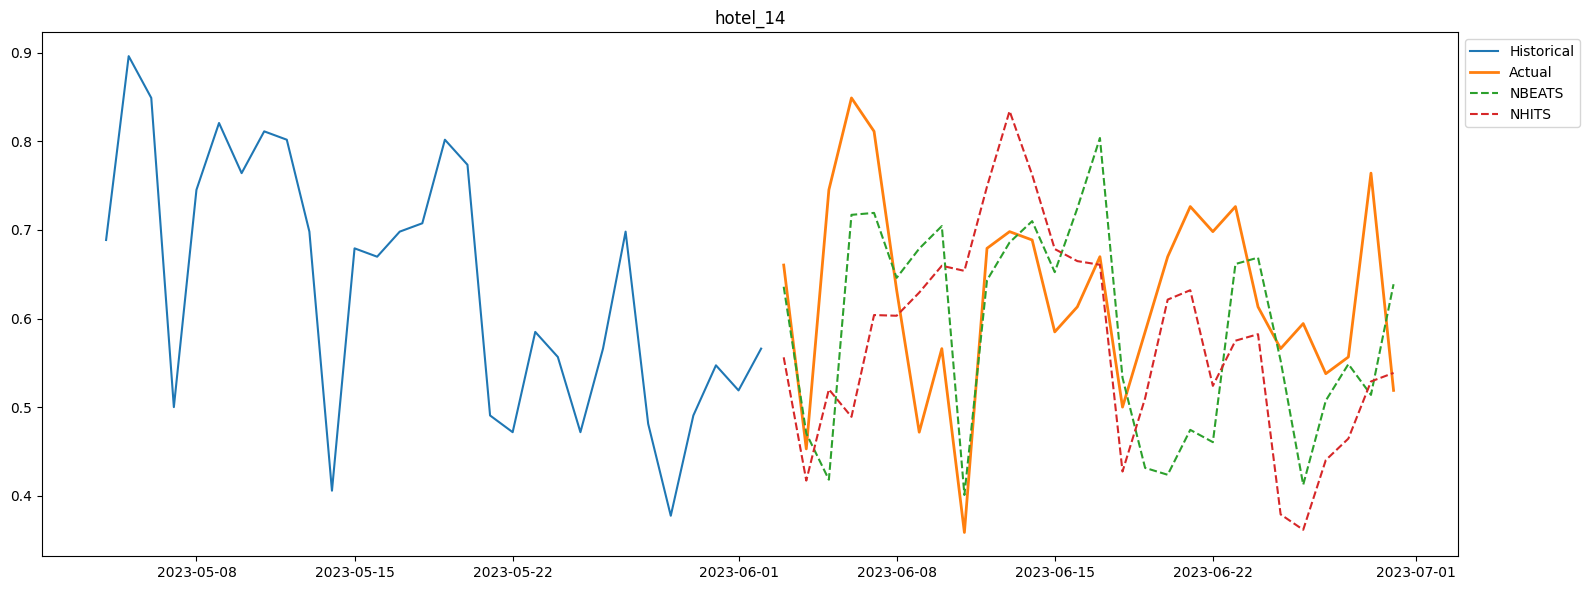

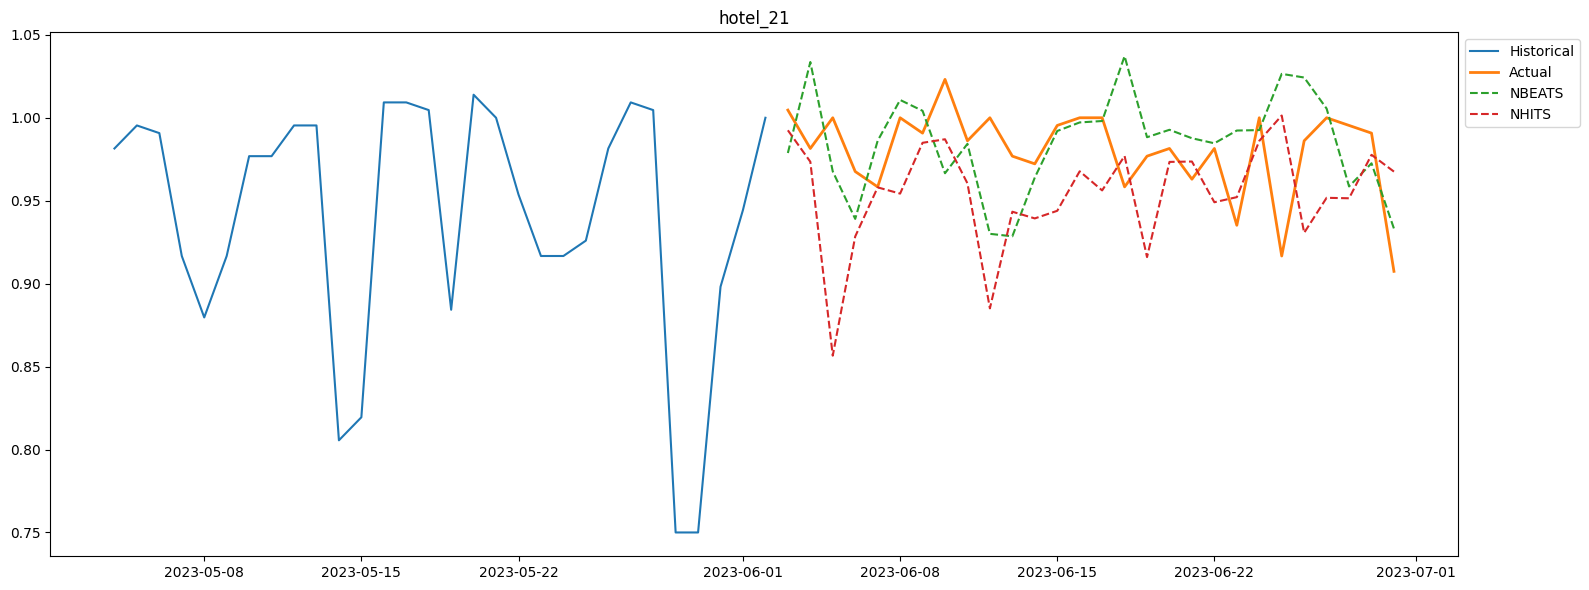

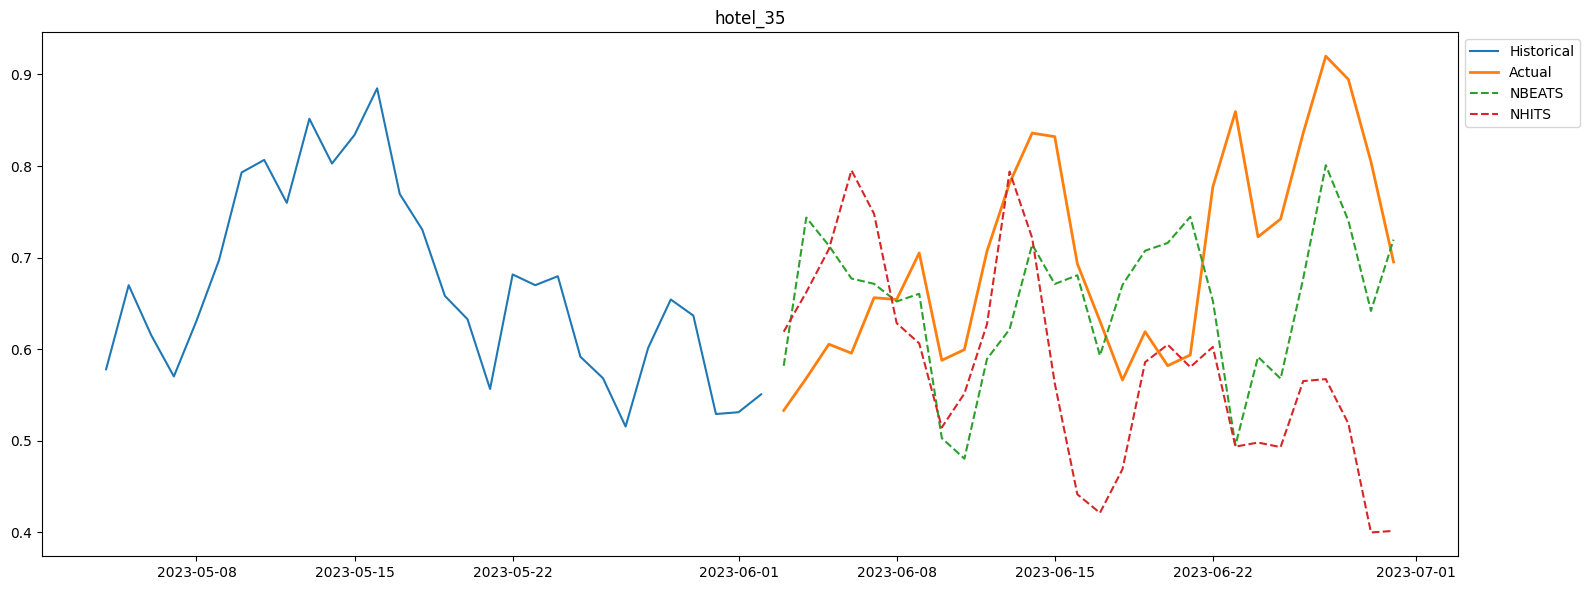

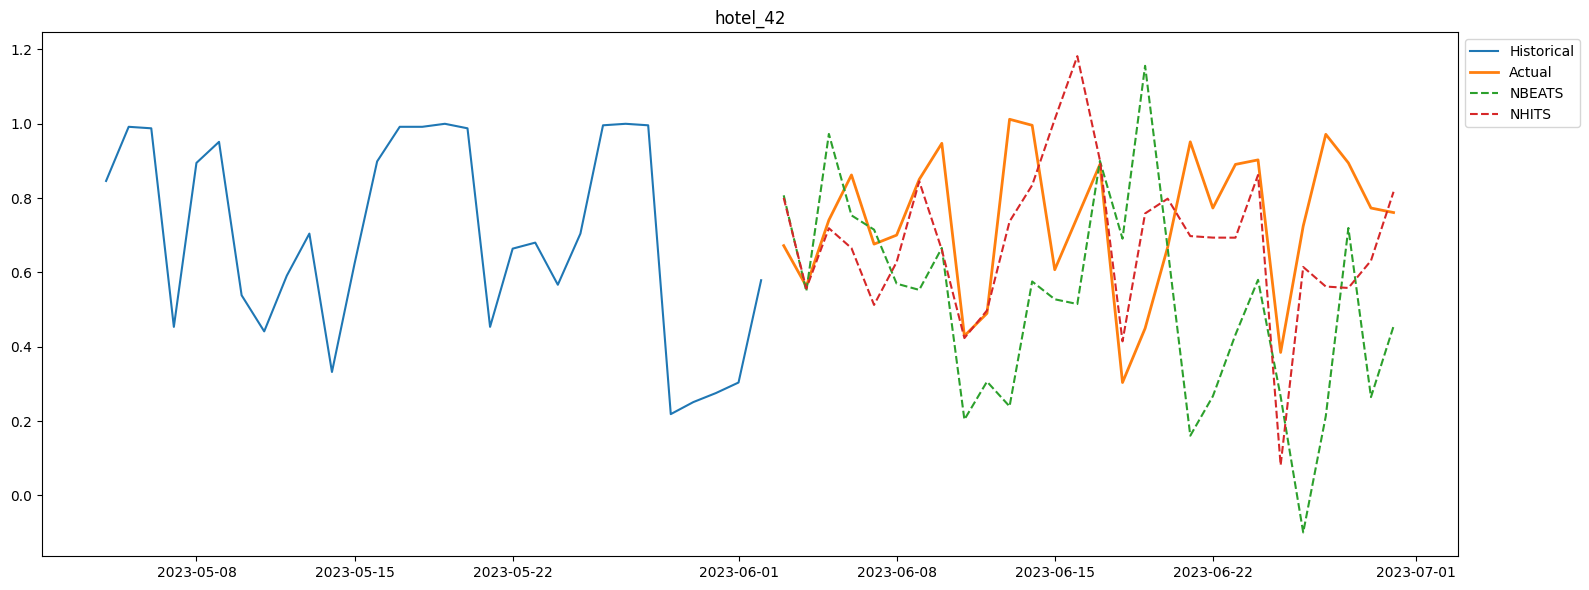

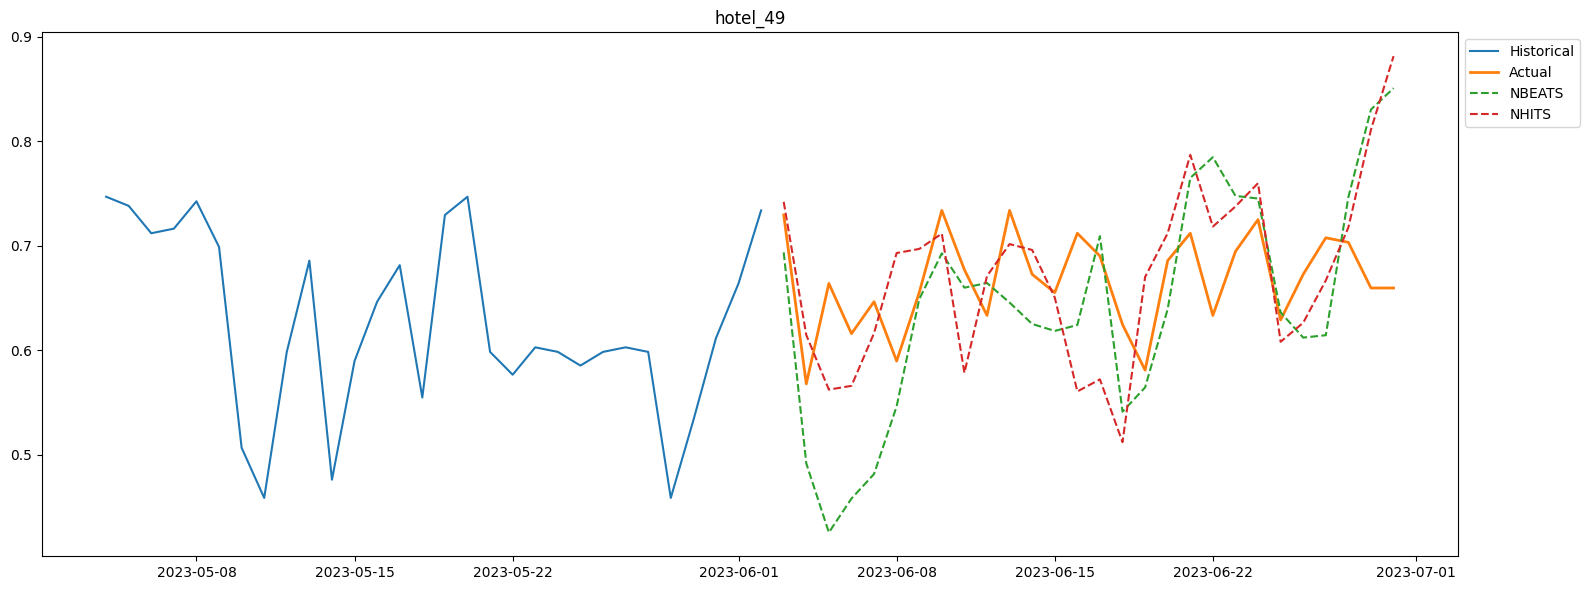

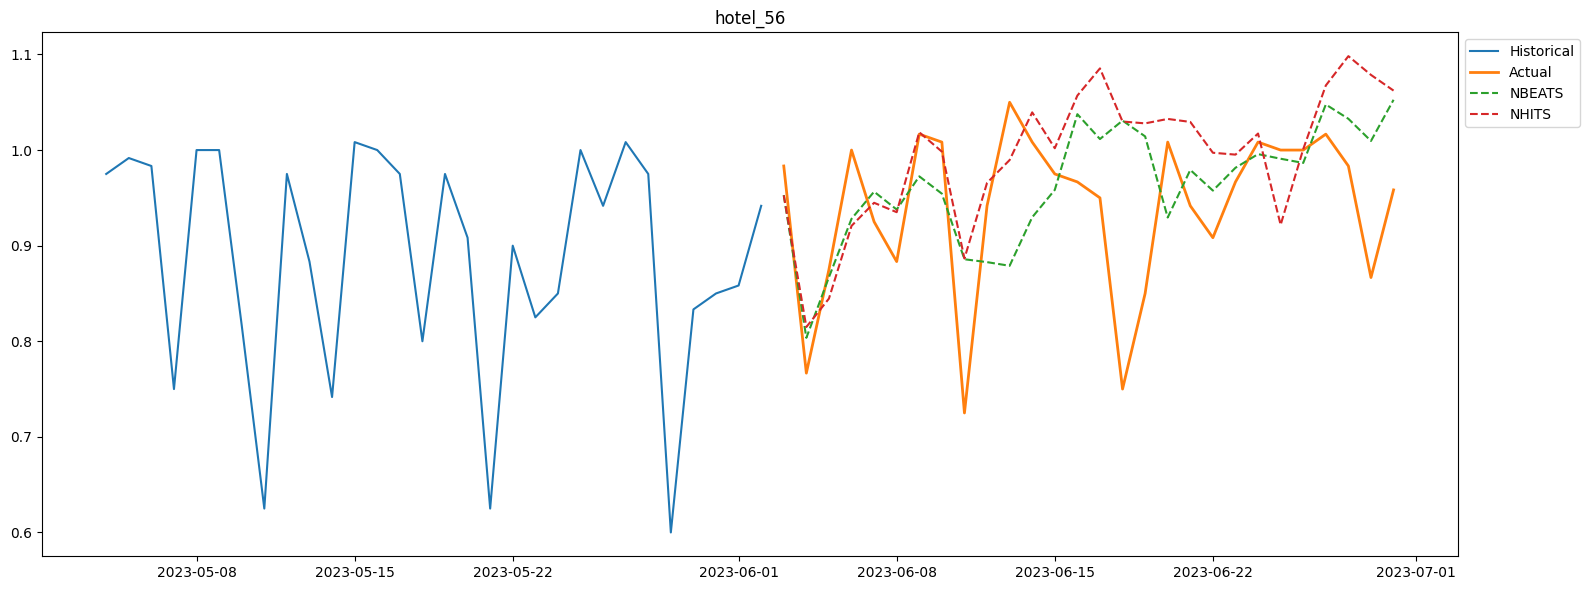

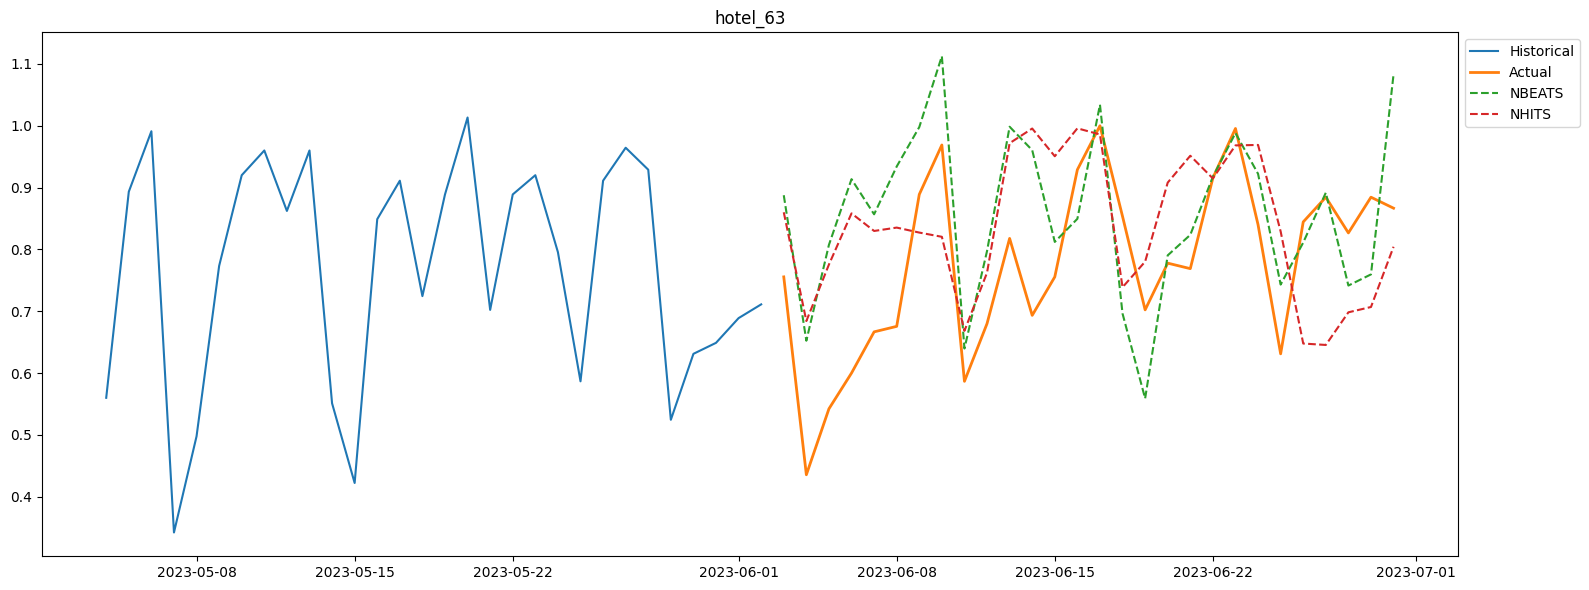

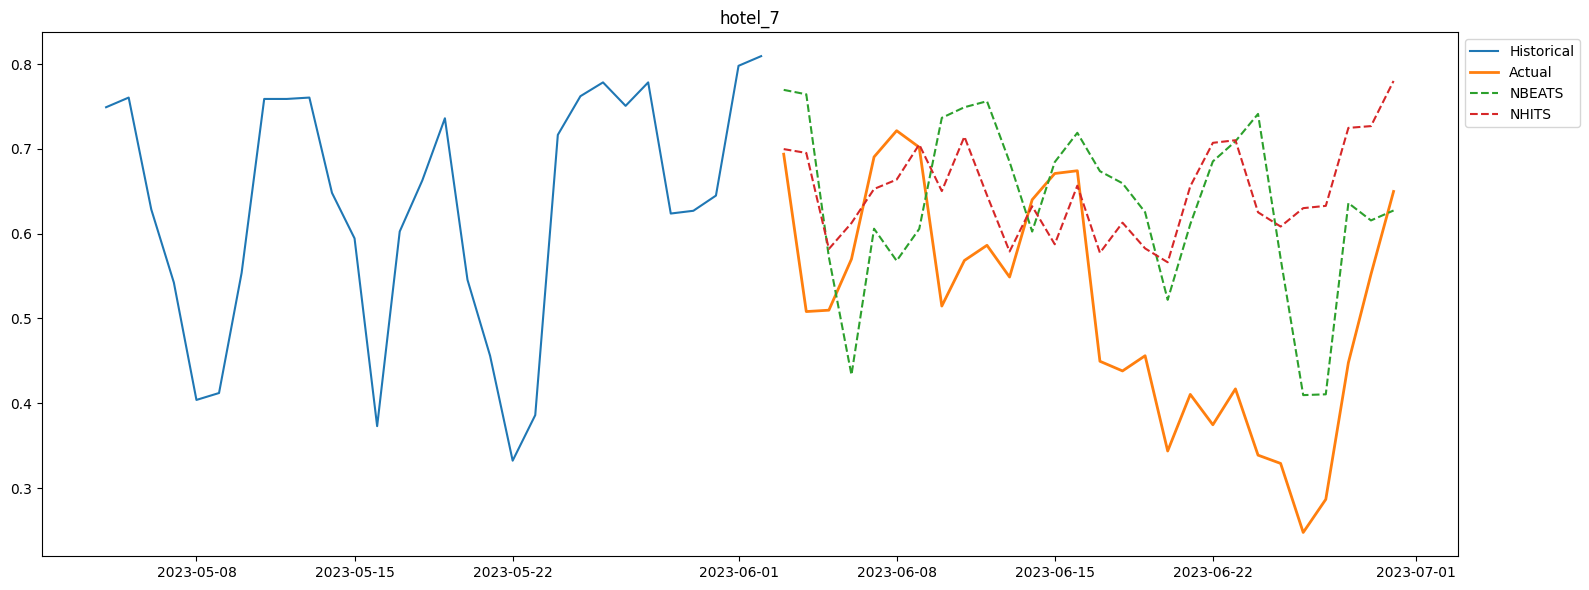

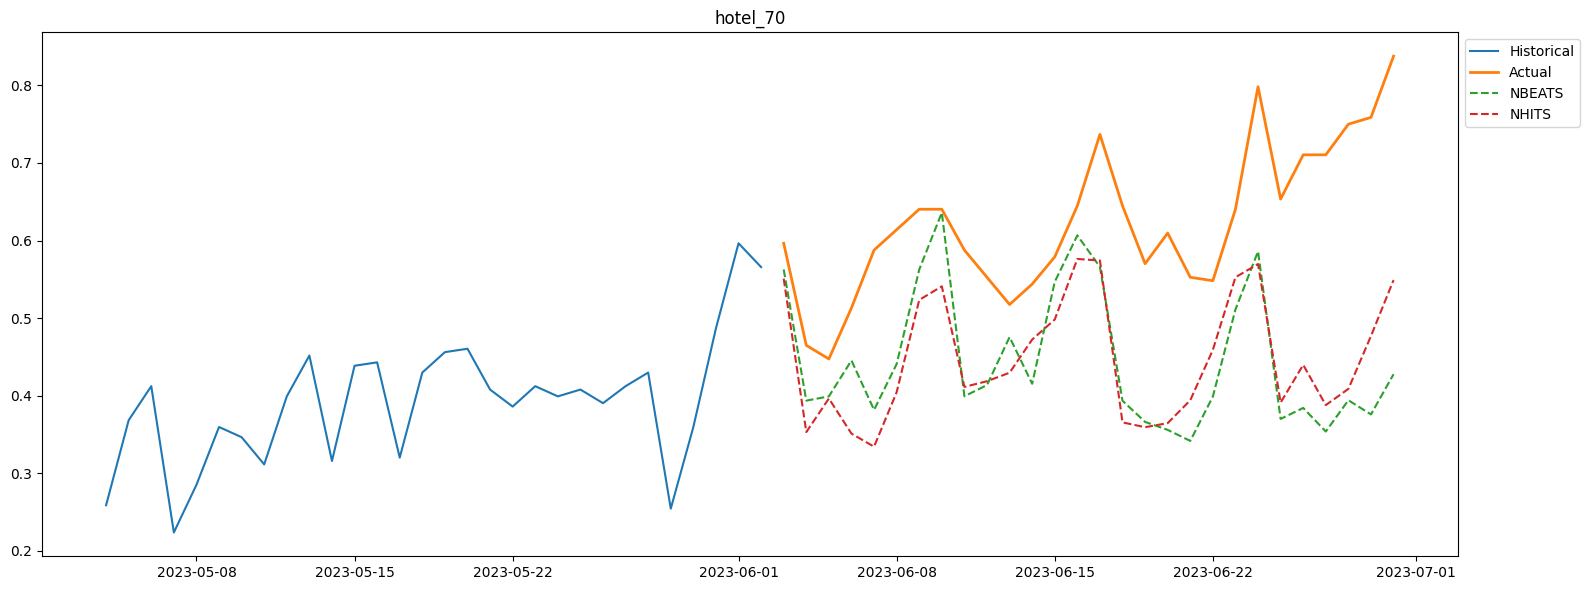

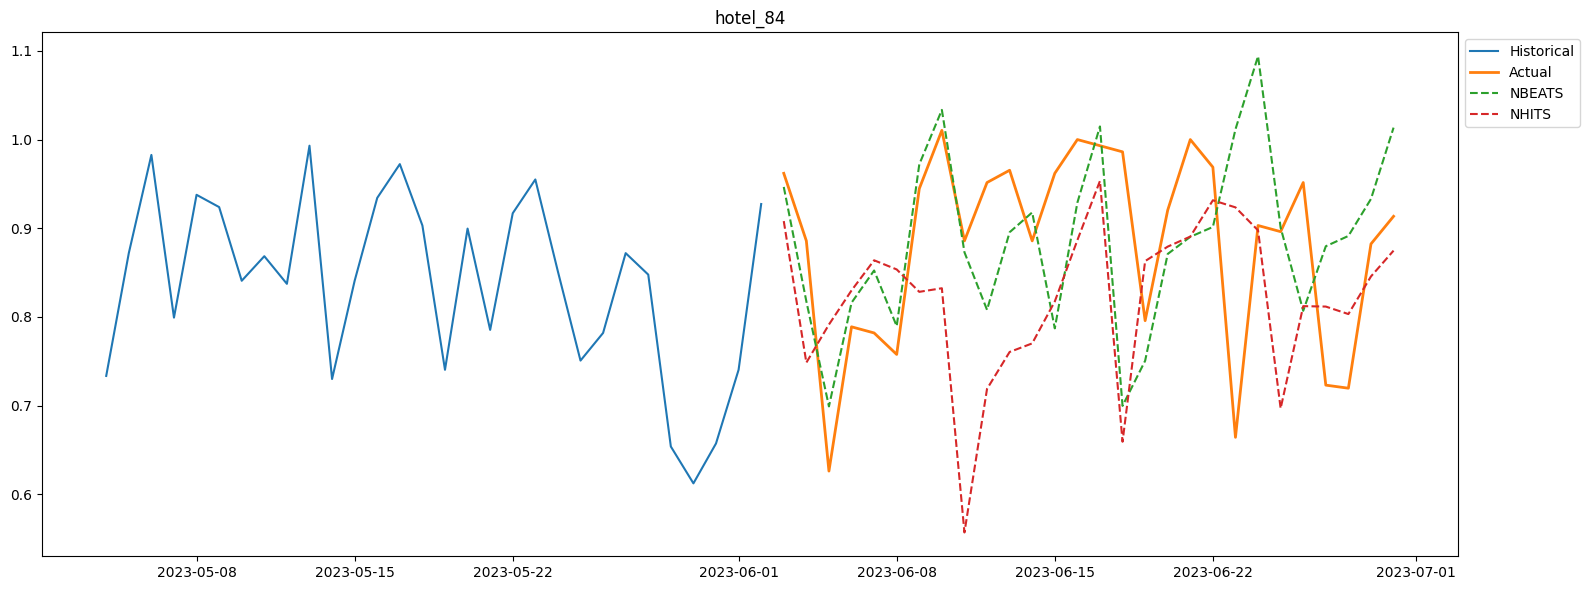

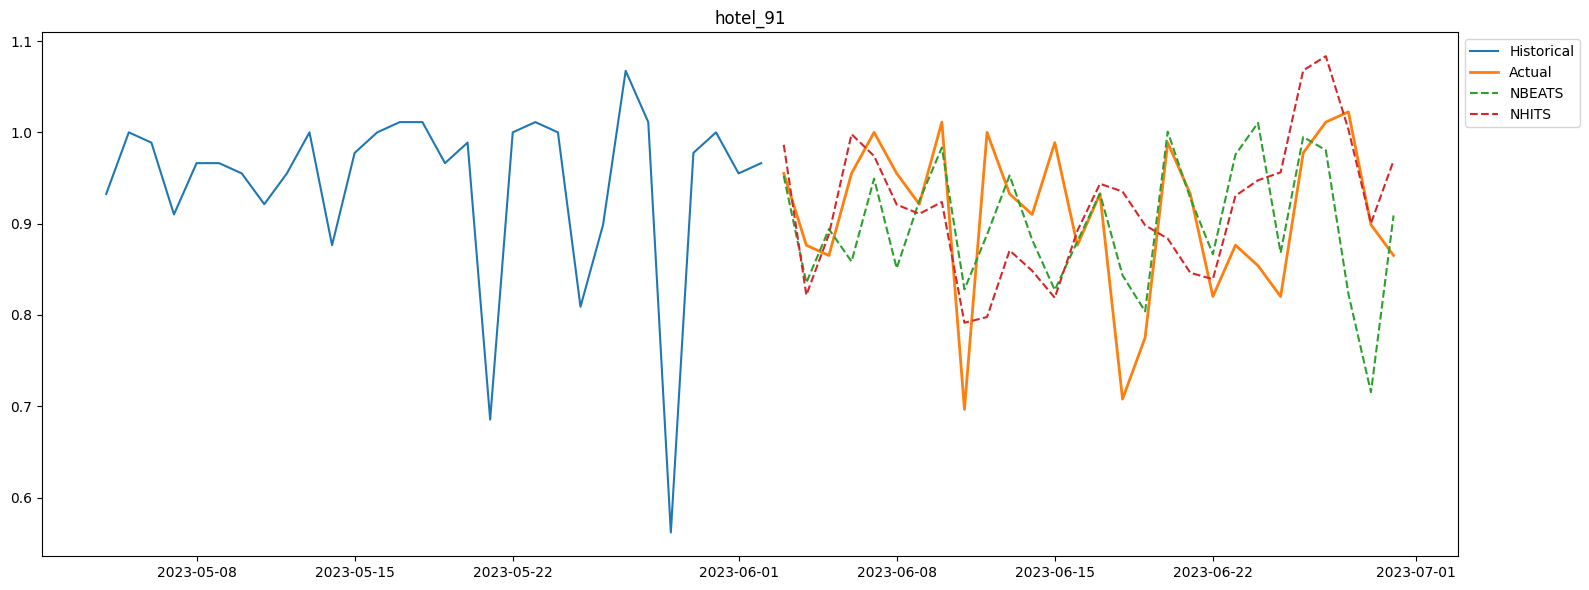

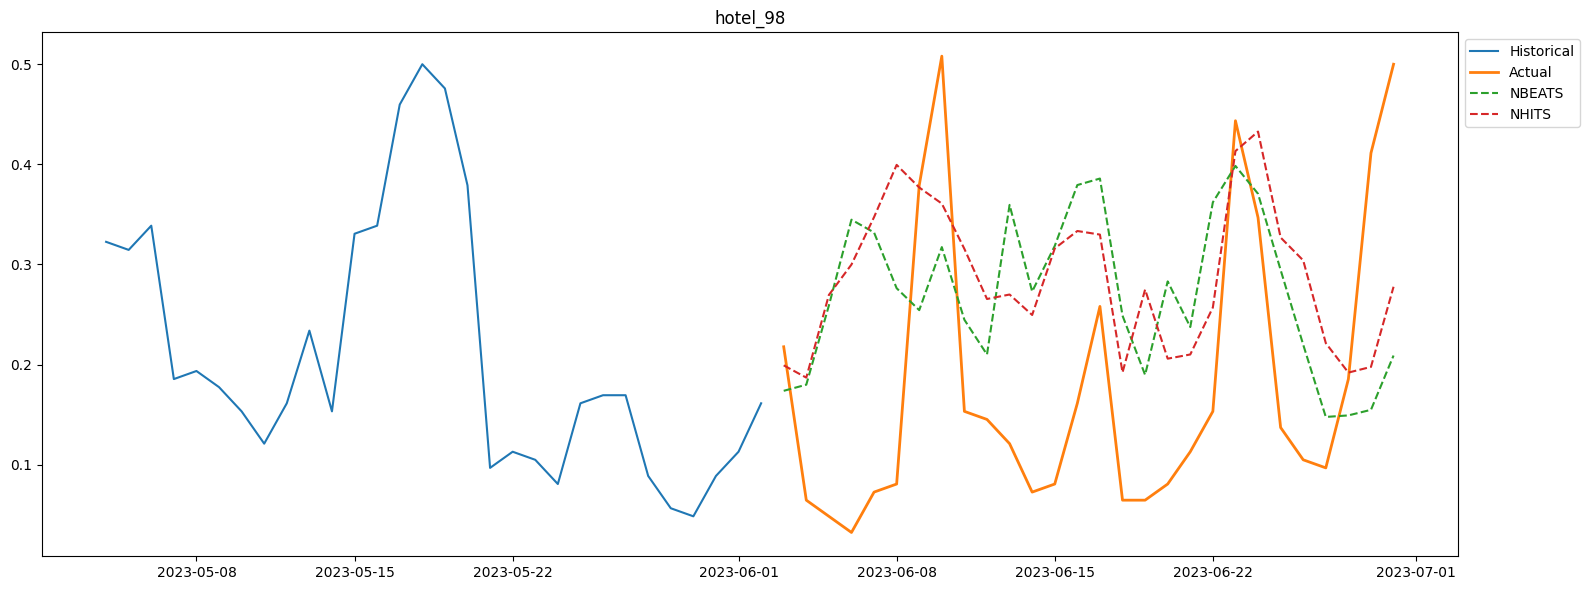

In [ ]:
import matplotlib.pyplot as plt

for hotel_id in results_test_nf['unique_id'].unique():
    actual  = test_df[test_df['unique_id'] == hotel_id]
    preds   = results_test_nf[results_test_nf['unique_id'] == hotel_id]
    history = train_df[train_df['unique_id'] == hotel_id].tail(30)

    plt.figure(figsize=(16, 6))
    plt.plot(history['ds'], history['y'], label='Historical')
    plt.plot(actual['ds'], actual['y'], label='Actual', linewidth=2)
    plt.plot(preds['ds'], preds['NBEATS'], label='NBEATS', linestyle='--')
    plt.plot(preds['ds'], preds['NHITS'], label='NHITS', linestyle='--')
    plt.title(hotel_id)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()